In [23]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [24]:
data = pd.read_csv('./DL/imdb.csv')
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [25]:
# Convert labels
le = LabelEncoder()
data['sentiment'] = le.fit_transform(data['sentiment'])

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    data['review'], data['sentiment'], test_size=0.2
)

In [27]:
# Convert text to number
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

In [28]:
#Converts sentences into numbers
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)
# "This movie is good"
# → [45, 2, 19, 1]
# Make all reviews same length
X_train = pad_sequences(X_train, maxlen=100)
X_test = pad_sequences(X_test, maxlen=100)

In [29]:
model = Sequential()
model.add(Embedding(5000, 16))
model.add(GlobalAveragePooling1D())
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [30]:
# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train model
model.fit(X_train, y_train, epochs=3)

# Test accuracy
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8059 - loss: 0.4343
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8751 - loss: 0.2966
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8838 - loss: 0.2754
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8643 - loss: 0.3213    
Accuracy: 0.864300012588501


In [31]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  


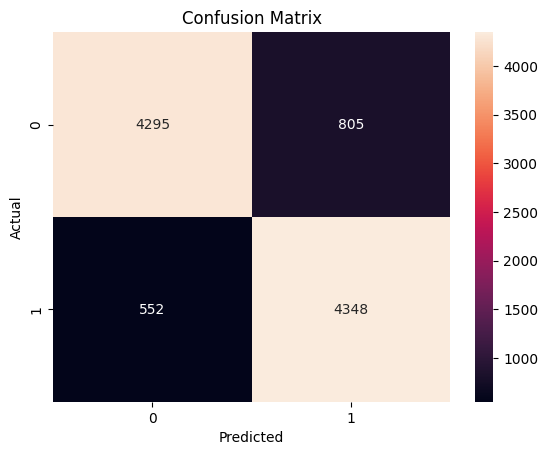


Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.84      0.86      5100
           1       0.84      0.89      0.87      4900

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



In [32]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict on test data
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

In [33]:
# 1. The "Correct" Diagonal (The Successes)
# These are the light-colored boxes where the Actual label matches the Predicted label.

# Top-Left (4295): True Negatives (TN)

# These were negative reviews, and your model correctly guessed they were negative.

# Bottom-Right (4348): True Positives (TP)

# These were positive reviews, and your model correctly guessed they were positive.

# 2. The "Error" Boxes (The Mistakes)
# These are the dark-colored boxes where the model tripped up.

# Top-Right (805): False Positives (FP)

# The review was actually Negative, but the model mistakenly predicted it as Positive. (Also called a "Type I Error").

# Bottom-Left (552): False Negatives (FN)

# The review was actually Positive, but the model mistakenly predicted it as Negative. (Also called a "Type II Error").

In [2]:
# ❓1. What is the aim of this practical?

# 👉 To classify movie reviews as positive or negative using a Deep Neural Network.

# ❓2. Is this classification or regression?

# 👉 Classification
# Because output is categorical (positive/negative).

# ❓3. Why is it called binary classification?

# 👉 Because there are only 2 classes:

# Positive (1)
# Negative (0)
# ❓4. Why can’t we directly give text to neural network?

# 👉 Neural networks only understand numbers, not text.

# ❓5. How did you convert text into numbers?

# 👉 Using Tokenizer:

# Converts words → integer indices
# ❓6. What does num_words=5000 mean?

# 👉 Only the top 5000 most frequent words are considered.

# 👉 Rare words are ignored.

# ❓7. What is tokenization?

# 👉 Process of splitting text into words and assigning each word a number.

# ❓8. What is padding and why is it required?

# 👉 Padding makes all sequences same length.

# 👉 Required because neural networks need fixed-size input.

# ❓9. What is maxlen=100?

# 👉 Each review is converted into a sequence of 100 words (fixed size).

# ❓10. What is an Embedding layer?

# 👉 Converts word indices into dense vectors (meaningful representations).

# ❓11. Why use Embedding instead of raw numbers?

# 👉 Raw numbers have no meaning, but embeddings capture semantic relationships between words.

# ❓12. What does Embedding(5000,16) mean?

# 👉

# 5000 → vocabulary size
# 16 → vector size for each word
# ❓13. What is GlobalAveragePooling1D?

# 👉 It converts a sequence of vectors into a single vector by averaging.

# 👉 Reduces complexity.

# ❓14. Why use ReLU activation?

# 👉 It introduces non-linearity and helps model learn complex patterns.

# ❓15. Why use sigmoid in output layer?

# 👉 Because:

# Output must be between 0 and 1
# Suitable for binary classification
# ❓16. What does sigmoid output represent?

# 👉 Probability:

# 0.8 → 80% positive
# 0.2 → 20% positive (so negative)
# ❓17. Why use binary_crossentropy loss?

# 👉 Because problem is binary classification.

# ❓18. What is accuracy?

# 👉 Percentage of correctly predicted samples.

# ❓19. What is an epoch?

# 👉 One complete pass through the entire dataset.

# ❓20. Why only 3 epochs?

# 👉 To reduce training time and avoid overfitting (basic model).

# 🔥 INTERMEDIATE (they may go deeper)
# ❓21. What happens if you increase epochs?

# 👉

# Model may improve
# But too many → overfitting
# ❓22. What is overfitting?

# 👉 Model performs well on training data but poorly on new data.

# ❓23. What is confusion matrix?

# 👉 A table showing:

# True Positive
# False Positive
# True Negative
# False Negative
# ❓24. What is precision?

# 👉 Out of predicted positives, how many are actually correct.

# ❓25. What is recall?

# 👉 Out of actual positives, how many are correctly predicted.

# ❓26. What is F1-score?

# 👉 Harmonic mean of precision and recall.

# 🔥 TRICKY QUESTIONS (very common)
# ❓27. Why not use softmax instead of sigmoid?

# 👉

# Softmax → multi-class classification
# Sigmoid → binary classification
# ❓28. What happens if you don’t use padding?

# 👉 Model will crash because input sizes differ.

# ❓29. Why not use raw word indices directly (without embedding)?

# 👉 Because numbers like 1, 2, 3 don’t represent meaning → embedding fixes this.

# ❓30. Can this model understand grammar?

# 👉 No, it only learns patterns — not true language understanding.

# ❓31. What are limitations of this model?

# 👉

# Ignores word order (due to averaging)
# Cannot capture context deeply
# Simple compared to LSTM/Transformers
# ❓32. How can you improve this model?

# 👉

# Use LSTM / GRU
# Use pretrained embeddings (Word2Vec, GloVe)
# Use BERT
# 🧠 ONE POWER ANSWER (high scoring)

# If examiner asks:

# 👉 “Why does this model work?”

# Answer:

# The model works because it converts text into numerical representations using tokenization and embedding. The embedding layer captures semantic meaning of words, and the neural network learns patterns that distinguish positive and negative sentiment. The sigmoid activation outputs probability for binary classification.